In [1]:
import warnings

warnings.filterwarnings("ignore")

import os

import pycountry
import plotly.express as px
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, fbeta_score, make_scorer, PrecisionRecallDisplay

from sklearn.calibration import CalibrationDisplay


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 45
np.random.seed(RANDOM_STATE)

CUR_DIR = os.getcwd()
BOOKS_DATA_PATH = os.path.join(CUR_DIR, "books_data/books.csv")
RATINGS_DATA_PATH = os.path.join(CUR_DIR, "books_data/ratings.csv")
USERS_DATA_PATH = os.path.join(CUR_DIR, "books_data/users.csv")

df_books = pd.read_csv(BOOKS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"', escapechar="\\").drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])
df_ratings = pd.read_csv(RATINGS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"')
df_users = pd.read_csv(USERS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"', escapechar="\\", index_col=0)

print(f"Books data    loaded {len(df_books):,} rows, {df_books.shape[1]} columns.")
print(f"Ratings data  loaded {len(df_ratings):,} rows, {df_ratings.shape[1]} columns.")
print(f"Users data    loaded {len(df_users):,} rows, {df_users.shape[1]} columns.")

df_active_countries = df_users['Location'].str.split(',').str[-1].str.strip()
unique_active_countries = df_active_countries.unique()

Books data    loaded 271,379 rows, 5 columns.
Ratings data  loaded 1,149,780 rows, 3 columns.
Users data    loaded 278,858 rows, 2 columns.


In [2]:
"""
METHOD 1
"""
countries = []
for country in pycountry.countries:
    countries.append(country.name.lower())

mutual = []
for mutual_country in countries:
    if mutual_country in unique_active_countries:
        mutual.append(mutual_country)

#ADD MANUALLY countries not in mutual
mutual += "usa", "russia", "iran", "vietnam", "u.a.e", "turkey", "taiwan", "syria", "venezuela", "south korea", "czech republic"
 
total_users_method1 = 0
for country in mutual:
    total_users_method1 += df_active_countries[df_active_countries == country].count()
print(f"Percentage of users kept after cleaning;            METHOD 1: {round(total_users_method1/len(df_users)*100, 2)}")

"""
METHOD 2
this is an additional validation step of the mutual list
"""
countries_counts = df_active_countries.value_counts()
counts_list = countries_counts[countries_counts>50].index.tolist()
counts_list.remove("")

total_users_method2 = 0
for country in counts_list:
    total_users_method2 += df_active_countries[df_active_countries == country].count()
print(f"Percentage of users kept after cleaning; only using METHOD 2: {round(total_users_method2/len(df_users)*100, 2)}")
print(f"Countries, having more than 50 customers, excluded from the countries list are: {set(counts_list)- set(mutual)}")

df_users['Country'] = df_users['Location'].str.split(',').str[-1].str.strip().str.lower()
df_users['Country'] = df_users['Country'].apply(lambda x: x if x in mutual else "unknown")

Percentage of users kept after cleaning;            METHOD 1: 97.92
Percentage of users kept after cleaning; only using METHOD 2: 97.38
Countries, having more than 50 customers, excluded from the countries list are: {'españa', 'yugoslavia'}


In [ ]:
#merge all data into one table - df_main
df_main = pd.merge(df_ratings,df_users, how='left', on='User-ID')
df_main = pd.merge(df_main, df_books, how= 'left', on='ISBN')
df_main = df_main.drop(['Location','Country'], axis = 1)
#restricts data only to top publishers
top_publishers = df_main['Publisher'].value_counts().head(10).index.to_list()
df_main = df_main[df_main['Publisher'].isin(top_publishers)]

#creates book-read-count column
read_count = df_main['Book-Title'].value_counts()
read_count.name = 'book-read-count'

#creates author-read-count column
author_counts = df_main['Book-Author'].value_counts()
author_counts.name = 'author-read-count'

#adds author_counts and read_count to df_main
df_main = pd.merge(df_main, author_counts, how='left', on='Book-Author')
df_main = pd.merge(df_main, read_count, how='left', on='Book-Title')

#create df_book_list table for recommendation system
df_book_list = (
    df_main[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Year-Of-Publication',
            'Publisher',
            'book-read-count',
            'author-read-count'
        ]
    ]
    .drop_duplicates('ISBN')
    .copy()
)

## Book ISBN search based on title for future actions


In [32]:
def search_books_by_title(search_text, n=10):
    """
    Search books by title so you can find the correct ISBN.
    """
    search_text = str(search_text).lower()

    results = df_book_list[
        df_book_list['Book-Title']
        .astype(str)
        .str.lower()
        .str.contains(search_text, na=False)
    ].copy()

    results = results.sort_values(
        by='book-read-count',
        ascending=False
    )

    return results.head(n)

In [33]:
search_books_by_title("Angels", n=10) 

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,book-read-count,author-read-count
4293,0345348109,The Killer Angels,Michael Shaara,1993.0,Ballantine Books,128,122
12341,034540727X,The Killer Angels,MICHAEL SHAARA,1996.0,Ballantine Books,128,18
298245,0345322282,The Killer Angels,Michael Shaara,1983.0,Ballantine Books,128,122
13693,0060008032,Angels,Marian Keyes,2003.0,HarperTorch,105,576
48508,034531820X,Angels,Denis Johnson,1984.0,Ballantine Books,105,28
5526,0446607274,Angels Flight (Detective Harry Bosch Mysteries),Michael Connelly,2000.0,Warner Books,50,492
4686,0446356611,Rage of Angels,Sidney Sheldon,1988.0,Warner Books,42,874
33182,0446341894,Rage of Angels,Sidney Sheldon,1985.0,Warner Books,42,874
5934,0373711646,Those Christmas Angels (Harlequin Superromance...,Debbie Macomber,2003.0,Harlequin,37,346
20,0140062718,The Rebel Angels,Robertson Davies,1983.0,Penguin Books,25,183


## Co-reader vote recommender

## Recommendation model logic

This recommender uses a co-reader voting approach. The input is a list of seed books represented by ISBNs. The model first finds users who are connected to these seed books, then recommends other books read by those users.

The function has two cases controlled by `k`:

- If `k = 0`, the model uses normal co-reader voting. A user counts as a match if they read or interacted with at least one input book.
- If `k != 0`, the model uses liked-seed voting. A user only counts as a match if they rated at least one input book with a rating greater than or equal to `k`.

For each matched user, the model counts how many input books they matched. This count becomes their vote weight. Other books read by that user receive votes equal to this weight. For example, if a user matched 2 input books, every other book they read receives 2 votes.

The model then calculates:

- `coreader_vote_score` or `liked_seed_vote_score`: total weighted votes a candidate book received.
- `matched_reader_count`: number of matched users who read the candidate book.
- `global_reader_count`: number of users in the whole cleaned dataset who read the candidate book.

The final recommendations are the books with the highest vote scores, excluding the original input books.

In [ ]:
def recommender(seed_isbns, k):
    # Clean input ISBNs
    seed_isbns = [str(isbn).strip() for isbn in seed_isbns]
    seed_isbns = list(set(seed_isbns))

    # Read/interacted events from df_main
    read_events = df_main[["User-ID", "ISBN"]].drop_duplicates()

    # Keep only seed books that exist in df_main
    valid_seed_isbns = [
        isbn for isbn in seed_isbns
        if isbn in set(df_main["ISBN"])
    ]

    print("Input seed ISBNs:", seed_isbns)
    print("Valid seed ISBNs:", valid_seed_isbns)

    if len(valid_seed_isbns) == 0:
        raise ValueError("None of the seed ISBNs exist in df_main.")



    # Case 1: k = 0
    # users count if they read/interacted with seed books
    if k == 0:
        print("Mode: co-reader votes based on read/interacted seed books")

        seed_reads = read_events[ read_events["ISBN"].isin(valid_seed_isbns)].copy()

        if seed_reads.empty:
            raise ValueError("No users read the selected seed books.")

        user_seed_matches = (seed_reads.groupby("User-ID")["ISBN"].nunique())
        user_seed_matches.name = "seed_match_count"
        user_seed_matches = user_seed_matches.reset_index()

        score_column = "seed_match_count"
        final_score_name = "coreader_vote_score"

    # Case 2: k != 0
    # Liked-seed logic:
    # users count only if they rated seed books >= k
    else:
        print("Mode: liked-seed votes based on seed ratings >= k")
        print("rating threshold:", k)

        liked_seed_ratings = df_main[(df_main["ISBN"].isin(valid_seed_isbns)) & (df_main["Book-Rating"] >= k)].copy()

        if liked_seed_ratings.empty:
            raise ValueError("No users rated the seed books above or equal to k.")

        user_seed_matches = (liked_seed_ratings.groupby("User-ID")["ISBN"].nunique())
        user_seed_matches.name = "liked_seed_count"
        user_seed_matches = user_seed_matches.reset_index()

        score_column = "liked_seed_count"
        final_score_name = "liked_seed_vote_score"
    print("Matched users:", len(user_seed_matches))



    # Get all other books read by matched users
    candidate_reads = pd.merge(read_events, user_seed_matches, how="inner", on="User-ID")

    # Do not recommend the input seed books
    candidate_reads = candidate_reads[~candidate_reads["ISBN"].isin(valid_seed_isbns)].copy()
    if candidate_reads.empty:
        return pd.DataFrame()

    # Score candidate books
    scores = (
        candidate_reads
        .groupby("ISBN")
        .agg(
            vote_score=(score_column, "sum"),
            matched_reader_count=("User-ID", "nunique")
        ).reset_index())
    scores = scores.rename(columns={"vote_score": final_score_name})

    # Global reader count
    global_reader_counts = (read_events.groupby("ISBN")["User-ID"].nunique())

    global_reader_counts.name = "global_reader_count"
    global_reader_counts = global_reader_counts.reset_index()

    scores = pd.merge(scores, global_reader_counts, how="left", on="ISBN")
    scores = scores.sort_values(by=[final_score_name, "matched_reader_count"], ascending=False)

    recommendations = pd.merge(scores, df_book_list, how="left", on="ISBN")

    return recommendations

## Recomender Test

In [35]:
seed_isbns = [
    "0451169530",   # The Stand
    "0451157443",   # Carrie
    "0743424425	",  # The Shining
    "0451184963",   # Insomnia
    "0345337662",   # Interview with the Vampire
    "0440295815",   # Hannibal
    "0399506438",   # Lord of the Flies
    "0345348109"    # The Killer Angels

]

In [36]:
recommender(seed_isbns, k=0)

Input seed ISBNs: ['0451169530', '0451184963', '0440295815', '0399506438', '0345348109', '0451157443', '0743424425', '0345337662']
Valid seed ISBNs: ['0451169530', '0451184963', '0440295815', '0399506438', '0345348109', '0451157443', '0743424425', '0345337662']
Mode: co-reader votes based on read/interacted seed books
Matched users: 898


,ISBN,coreader_vote_score,matched_reader_count,global_reader_count,Book-Title,Book-Author,Year-Of-Publication,Publisher,book-read-count,author-read-count
0,0345313860,228,181,301,"The Vampire Lestat (Vampire Chronicles, Book II)",ANNE RICE,1986.0,Ballantine Books,301,656
1,0440211727,199,136,517,A Time to Kill,JOHN GRISHAM,1992.0,Dell,520,1986
2,0345351525,182,146,273,The Queen of the Damned (Vampire Chronicles (P...,Anne Rice,1993.0,Ballantine Books,273,2291
3,0345370775,181,128,466,Jurassic Park,Michael Crichton,1999.0,Ballantine Books,468,1940
4,0440214041,179,127,523,The Pelican Brief,John Grisham,1993.0,Dell,523,3181
...,...,...,...,...,...,...,...,...,...,...
31538,2266107534,1,1,3,La citÃ?Â© de la joie,Dominique Lapierre,2000.0,Pocket,3,26
31539,2266110527,1,1,1,Le Sphinx,Graham Masterton,2001.0,Pocket,1,18
31540,2266130307,1,1,1,Les trois enquÃ?Âªtes du chevalier Dupin,Edgar Allan Poe,2003.0,Pocket,1,70
31541,5553859271,1,1,1,I'll Take Manhatten,Judith Krantz,1992.0,Bantam Books,1,365


In [37]:
recommender(seed_isbns,k=8)

Input seed ISBNs: ['0451169530', '0451184963', '0440295815', '0399506438', '0345348109', '0451157443', '0743424425', '0345337662']
Valid seed ISBNs: ['0451169530', '0451184963', '0440295815', '0399506438', '0345348109', '0451157443', '0743424425', '0345337662']
Mode: liked-seed votes based on seed ratings >= k
rating threshold: 8
Matched users: 298


,ISBN,liked_seed_vote_score,matched_reader_count,global_reader_count,Book-Title,Book-Author,Year-Of-Publication,Publisher,book-read-count,author-read-count
0,0345313860,69,67,301,"The Vampire Lestat (Vampire Chronicles, Book II)",ANNE RICE,1986.0,Ballantine Books,301,656
1,0345351525,55,53,273,The Queen of the Damned (Vampire Chronicles (P...,Anne Rice,1993.0,Ballantine Books,273,2291
2,0440211727,51,47,517,A Time to Kill,JOHN GRISHAM,1992.0,Dell,520,1986
3,034538475X,45,43,193,The Tale of the Body Thief (Vampire Chronicles...,Anne Rice,1993.0,Ballantine Books,193,2291
4,0451156609,41,34,170,The Tommyknockers,Stephen King,1994.0,Signet Book,170,5669
...,...,...,...,...,...,...,...,...,...,...
13894,2266120166,1,1,11,La Rage au coeur,Ingrid Betancourt,2002.0,Pocket,11,11
13895,2266130250,1,1,2,"Rupture dans le rÃ?Â©el, tome 1-1 : GÃ?Â©nÃ?Â©se",Peter F. Hamilton,2003.0,Pocket,2,24
13896,2266131516,1,1,4,La MÃ?Â©thode simple pour en finir avec la cig...,Allen Carr,2003.0,Pocket,4,4
13897,5553859271,1,1,1,I'll Take Manhatten,Judith Krantz,1992.0,Bantam Books,1,365


## Extra Data cleaning for Regression

In [38]:
#creates book-rate-count column
df_main = df_main[df_main['Book-Rating'] != 0]
rate_count = df_main['Book-Title'].value_counts()
rate_count.name = 'book-rate-count'

#adds rate_count to df_main
df_main = pd.merge(df_main, rate_count, how= 'left', on='Book-Title')

median_age = df_main['Age'].median()
df_main['Age'] = df_main['Age'].fillna(median_age)
K = 8
df_main['rating-over-k'] = df_main['Book-Rating'].apply(lambda row: 1 if row >= K else 0)

display(df_main)

NUM_COLS = [
    'book-rate-count',
    'book-read-count',
    'author-read-count',
    'Year-Of-Publication',
    'Age',
]
CAT_COLS = [
    'Publisher',
]
TARGET = 'rating-over-k'

,User-ID,ISBN,Book-Rating,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher,author-read-count,book-read-count,book-rate-count,rating-over-k
0,276747,0060517794,9,25.0,Little Altars Everywhere,Rebecca Wells,2003.0,HarperTorch,1623,68,31,1
1,276747,0671537458,9,25.0,Waiting to Exhale,Terry McMillan,1995.0,Pocket,419,88,17,1
2,276747,0679776818,8,25.0,Birdsong: A Novel of Love and War,Sebastian Faulks,1997.0,Vintage Books USA,77,47,21,1
3,276755,0451166892,5,32.0,The Pillars of the Earth,Ken Follett,1996.0,Signet Book,1067,228,87,0
4,276762,0380711524,5,25.0,See Jane Run,Joy Fielding,1992.0,Avon,197,46,16,0
...,...,...,...,...,...,...,...,...,...,...,...,...
124269,276688,0684804484,10,35.0,No Ordinary Time: Franklin and Eleanor Rooseve...,Doris Kearns Goodwin,1995.0,Simon &amp; Schuster,53,11,4,1
124270,276688,0743202694,10,35.0,"Money, Money, Money : A Novel of the 87th Prec...",Ed McBain,2001.0,Simon &amp; Schuster,278,11,9,1
124271,276704,0345386108,6,35.0,Winter Moon,Dean R. Koontz,1995.0,Ballantine Books,4004,144,39,0
124272,276709,0515107662,10,38.0,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996.0,Jove Books,1651,44,18,1


In [39]:
def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    numeric_step = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        [
            ("num", numeric_step, NUM_COLS),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                CAT_COLS,
            ),
        ]
    )

def make_pipeline_for(model_name: str, **params) -> Pipeline:
    if model_name == "logistic":
        estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **params)
        scale_numeric = True
    elif model_name == "tree":
        estimator = DecisionTreeClassifier(random_state=RANDOM_STATE, **params)
        scale_numeric = False
    elif model_name == "random_forest":
        estimator = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        scale_numeric = False
    elif model_name == "gradient_boosting":
        estimator = GradientBoostingClassifier(random_state=RANDOM_STATE, **params)
        scale_numeric = False
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return Pipeline(
        [
            ("pre", make_preprocessor(scale_numeric=scale_numeric)),
            ("model", estimator),
        ]
    )

# Base Cross-Validation Strategy
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

test_df = df_main.groupby('rating-over-k', group_keys=False).apply(lambda x: x.sample(frac=0.1))
#X = test_df[NUM_COLS+CAT_COLS]
#y = test_df[TARGET]

X = df_main[NUM_COLS+CAT_COLS]
y = df_main[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.8)

In [40]:
rf_grid = GridSearchCV(
    make_pipeline_for("random_forest"),
    param_grid={
        "model__n_estimators": [100],
        "model__max_depth": [10, 20, None],
        "model__min_samples_leaf": [1, 5],
    },
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_log_loss",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best_params = {k.replace("model__", ""): v for k, v in rf_grid.best_params_.items()}
print(f"Best RF Params: {rf_best_params}")

# Gradient Boosting GridSearch
gb_grid = GridSearchCV(
    make_pipeline_for("gradient_boosting"),
    param_grid={
        "model__n_estimators": [60, 100],
        "model__learning_rate": [0.05, 0.10],
        "model__max_depth": [2, 3],
    },
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_log_loss",
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)
gb_best_params = {k.replace("model__", ""): v for k, v in gb_grid.best_params_.items()}
print(f"Best GB Params: {gb_best_params}")

# Decision Tree GridSearch
dt_grid = GridSearchCV(
    make_pipeline_for("tree"),
    param_grid={
        "model__max_depth": [4, 6, 8, 10, None],
        "model__min_samples_leaf": [1, 10, 50, 100],
    },
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_log_loss",
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
dt_best_params = {k.replace("model__", ""): v for k, v in dt_grid.best_params_.items()}
print(f"Best DT Params: {dt_best_params}")

# Define the final candidate dictionary
candidate_models = {
    "Logistic Regression": make_pipeline_for("logistic"),
    "Shallow Tree": make_pipeline_for("tree", max_depth=4, min_samples_leaf=100),
    "Tuned Decision Tree": make_pipeline_for("tree", **dt_best_params),
    "Random Forest": make_pipeline_for("random_forest", **rf_best_params),
    "Gradient Boosting": make_pipeline_for("gradient_boosting", **gb_best_params),
}

Best RF Params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Best GB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best DT Params: {'max_depth': 4, 'min_samples_leaf': 50}


In [50]:
print("Generating OOF predictions and metrics...")

oof_predictions_dict = {}
model_results = []
fold_metrics_list = []

plt.figure(figsize=(10, 6))

for name, pipeline in candidate_models.items():
    # 1. Gather OOF Probabilities
    oof_probs = cross_val_predict(
        pipeline, X_train, y_train, cv=cv5, method="predict_proba", n_jobs=-1
    )[:, 1]
    oof_predictions_dict[name] = oof_probs
    
    # 2. Gather Fold-by-Fold metrics (for the swarm plots later)
    f05_scorer = make_scorer(fbeta_score, beta=0.5)
    cv_scores = cross_validate(pipeline, X_train, y_train, cv=cv5, scoring={'fbeta': f05_scorer, 'log_loss': 'neg_log_loss'})

    for fold_idx in range(cv5.get_n_splits()):
        fold_metrics_list.append({
            "Model": name,
            "Fold": fold_idx + 1,
            "F1 Score (Default 0.5)": cv_scores['test_fbeta'][fold_idx],
            "Neg Log-Loss": cv_scores['test_log_loss'][fold_idx]
        })
    
    # 3. Calculate Optimal Threshold
    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)

    beta = 0.5
    beta_sq = beta ** 2
    numerator = (1 + beta_sq) * (precisions * recalls)
    denominator = (beta_sq * precisions) + recalls
    fbeta_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
    
    best_idx = np.argmax(fbeta_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = fbeta_scores[best_idx]
    
    model_results.append({
        "Model": name,
        "Optimal Threshold": best_threshold,
        "Peak OOF F1-Score": best_f1
    })
    
    # Plot Threshold vs F1
    plt.plot(thresholds, fbeta_scores[:-1], label=f"{name} (Peak: {best_f1:.3f})", linewidth=2)

# Format the Threshold vs F1 Plot
plt.title("OOF F1-Score vs. Decision Threshold", fontsize=14)
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label="Default 0.5 Threshold")
plt.legend(loc="lower center")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display Summary Scorecard
summary_df = pd.DataFrame(model_results).sort_values(by="Peak OOF F1-Score", ascending=False)
display(summary_df.round(4).reset_index(drop=True))

# Extract winning details
best_model_name = summary_df.iloc[0]["Model"]
best_threshold = summary_df.iloc[0]["Optimal Threshold"]
winning_pipeline = candidate_models[best_model_name]

# Store CV metrics df
cv_metrics_df = pd.DataFrame(fold_metrics_list)


Generating OOF predictions and metrics...


,User-ID,ISBN,Book-Rating,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher,author-read-count,book-read-count,book-rate-count,rating-over-k
59812,129111,0394701577,6,35.0,The Immense Journey (Vintage),Loren C. Eiseley,1957.0,Vintage Books USA,13,13,3,0
41283,92979,0553379615,7,35.0,Into the Forest,JEAN HEGLAND,1998.0,Bantam,30,41,22,0
84202,184142,0451197372,5,35.0,A Midnight Clear: Stories for the Christmas Se...,Katherine Paterson,1998.0,Signet Book,9,4,1,0
28659,61028,0451200942,7,50.0,Fall to Pieces (Kate Banning Mysteries),Cecilia Tishy,2000.0,Signet Book,4,4,1,0
93530,207727,0451166892,5,37.0,The Pillars of the Earth,Ken Follett,1996.0,Signet Book,1067,228,87,0
...,...,...,...,...,...,...,...,...,...,...,...,...
115995,255856,0684809982,8,27.0,LATE CHILD,Larry McMurtry,1995.0,Simon &amp; Schuster,832,4,3,1
93342,207349,0380811065,8,25.0,Lady Sophia's Lover,Lisa Kleypas,2002.0,Avon,259,34,14,1
68627,150327,0345444922,8,35.0,Caroline Masters,Richard North Patterson,2000.0,Ballantine Books,638,6,2,1
83816,183101,0679752927,9,15.0,My Own Country: A Doctor's Story,A. Verghese,1995.0,Vintage Books USA,9,9,6,1


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: F1 Score (Default threshold) variance
sns.boxplot(data=cv_metrics_df, x="Model", y="F1 Score (Default 0.5)", color="white", ax=axes[0])
sns.swarmplot(data=cv_metrics_df, x="Model", y="F1 Score (Default 0.5)", size=8, ax=axes[0])
axes[0].set_title("CV F1-Score Stability (Default Threshold)", fontsize=13)
axes[0].set_ylabel("F1 Score")

# Subplot 2: Negative Log-Loss variance
sns.boxplot(data=cv_metrics_df, x="Model", y="Neg Log-Loss", color="white", ax=axes[1])
sns.swarmplot(data=cv_metrics_df, x="Model", y="Neg Log-Loss", size=8, ax=axes[1])
axes[1].set_title("CV Neg Log-Loss Stability", fontsize=13)
axes[1].set_ylabel("Negative Log-Loss (Higher is Better)")

plt.suptitle("Cross-Validation Fold Performance Distributions", fontsize=16)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

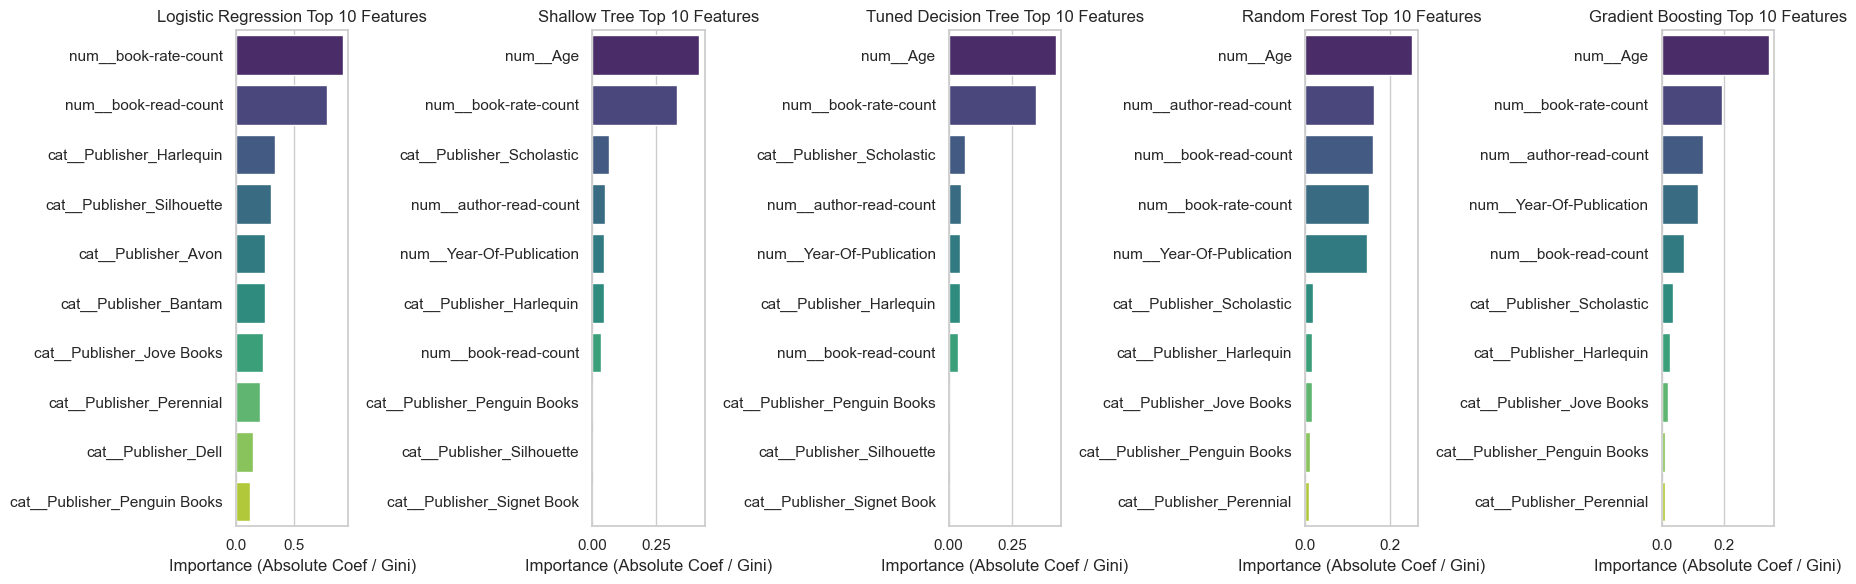

In [52]:
#  Feature Importances
# Fit all models on the full training set to extract and plot their most important features.

# %%
fig, axes = plt.subplots(1, len(candidate_models), figsize=(18, 6))

for idx, (name, pipeline) in enumerate(candidate_models.items()):
    # Fit the pipeline on the full training data
    pipeline.fit(X_train, y_train)
    
    # Extract feature names from the preprocessor (handles OneHotEncoded names)
    preprocessor = pipeline.named_steps['pre']
    model = pipeline.named_steps['model']
    feature_names_out = preprocessor.get_feature_names_out()
    
    # Extract importances (coefficients for Linear, importances for Trees)
    if hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        importances = model.feature_importances_
        
    # Sort and plot top 10
    feat_df = pd.DataFrame({'Feature': feature_names_out, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)
    
    sns.barplot(data=feat_df, x='Importance', y='Feature', ax=axes[idx], palette="viridis")
    axes[idx].set_title(f"{name} Top 10 Features")
    axes[idx].set_xlabel("Importance (Absolute Coef / Gini)")
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()

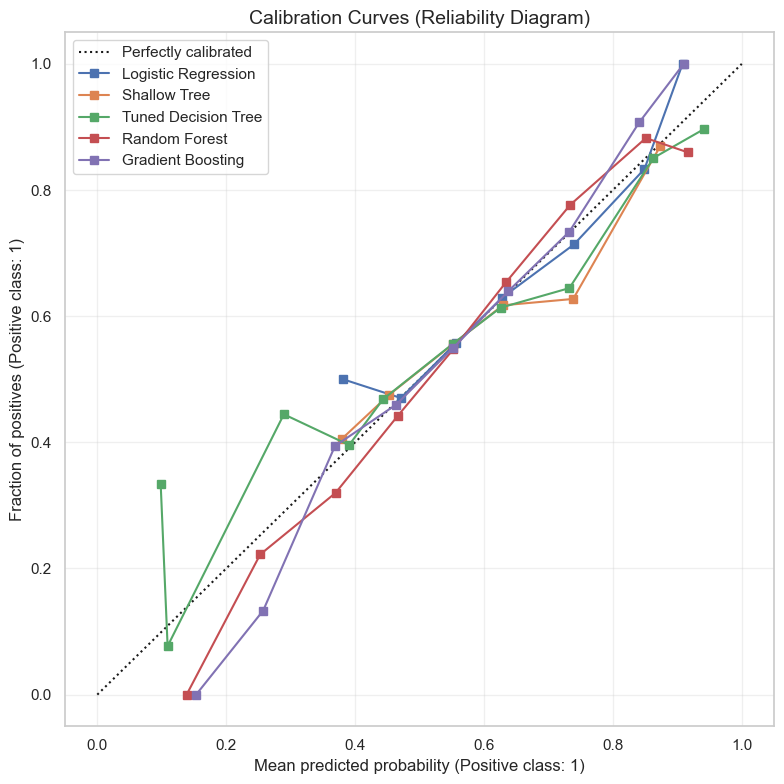

In [53]:
# Model Reliability (Calibration Curve)
# Ensure the out-of-fold predicted probabilities match actual observed frequencies.

plt.figure(figsize=(8, 8))
ax = plt.gca()

for name in candidate_models.keys():
    # We use the OOF probabilities calculated in Cell 4
    CalibrationDisplay.from_predictions(
        y_train, 
        oof_predictions_dict[name], 
        n_bins=10, 
        name=name, 
        ax=ax
    )

plt.title("Calibration Curves (Reliability Diagram)", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


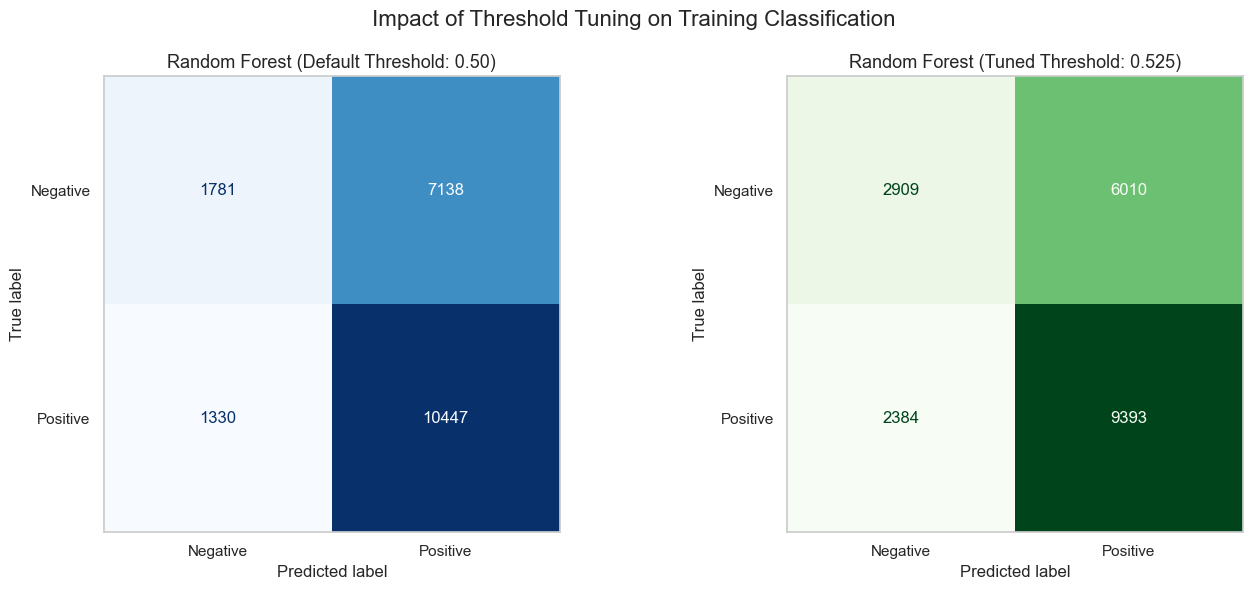

Done! The final 'Random Forest' pipeline is stored in `winning_pipeline`.
Remember to use (winning_pipeline.predict_proba(X_test)[:, 1] >= 0.525).astype(int) for future predictions!


In [54]:
# The Winning Model & Tuned Confusion Matrix
# optimized threshold redistributes errors for the winning model

# Extract winning OOF probabilities
winning_oof_probs = oof_predictions_dict[best_model_name]

# 1. Predict using default 0.5 threshold
y_pred_default = (winning_oof_probs >= 0.5).astype(int)

# 2. Predict using our tuned threshold
y_pred_tuned = (winning_oof_probs >= best_threshold).astype(int)

# Plot both to show the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_default = confusion_matrix(y_train, y_pred_default)
ConfusionMatrixDisplay(cm_default, display_labels=["Negative", "Positive"]).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d'
)
axes[0].set_title(f"{best_model_name} (Default Threshold: 0.50)", fontsize=13)
axes[0].grid(False)

cm_tuned = confusion_matrix(y_train, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned, display_labels=["Negative", "Positive"]).plot(
    ax=axes[1], cmap='Greens', colorbar=False, values_format='d'
)
axes[1].set_title(f"{best_model_name} (Tuned Threshold: {best_threshold:.3f})", fontsize=13)
axes[1].grid(False)

plt.suptitle("Impact of Threshold Tuning on Training Classification", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Done! The final '{best_model_name}' pipeline is stored in `winning_pipeline`.")
print(f"Remember to use (winning_pipeline.predict_proba(X_test)[:, 1] >= {best_threshold:.3f}).astype(int) for future predictions!")


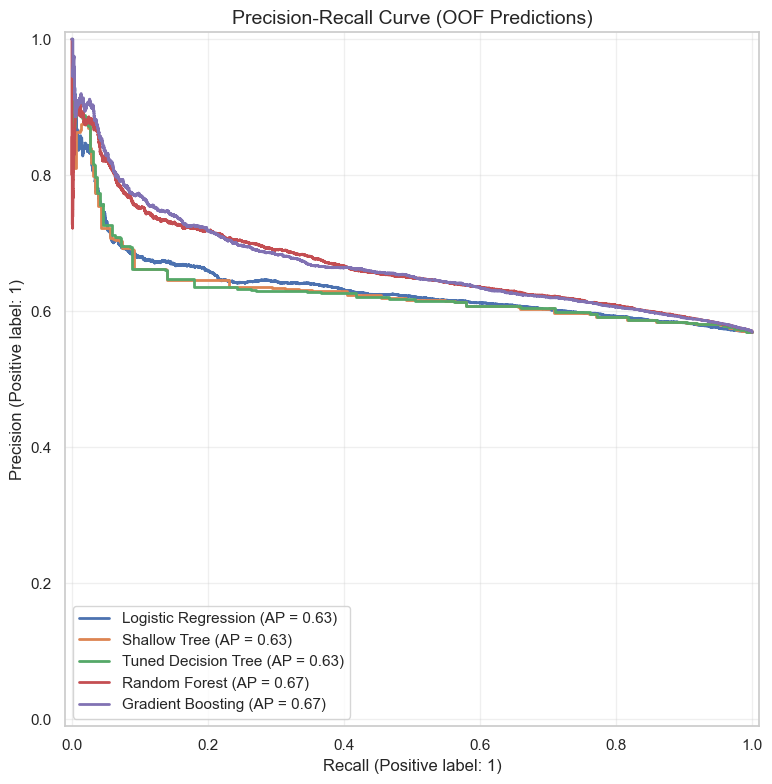

In [55]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

for name in candidate_models.keys():
    # Plot the PR curve using our OOF probabilities
    PrecisionRecallDisplay.from_predictions(
        y_train, 
        oof_predictions_dict[name], 
        name=name, 
        ax=ax,
        linewidth=2
    )

plt.title("Precision-Recall Curve (OOF Predictions)", fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()